Dataset Shape: (366, 35)

Missing Values:
erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_infiltrate                      0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges         

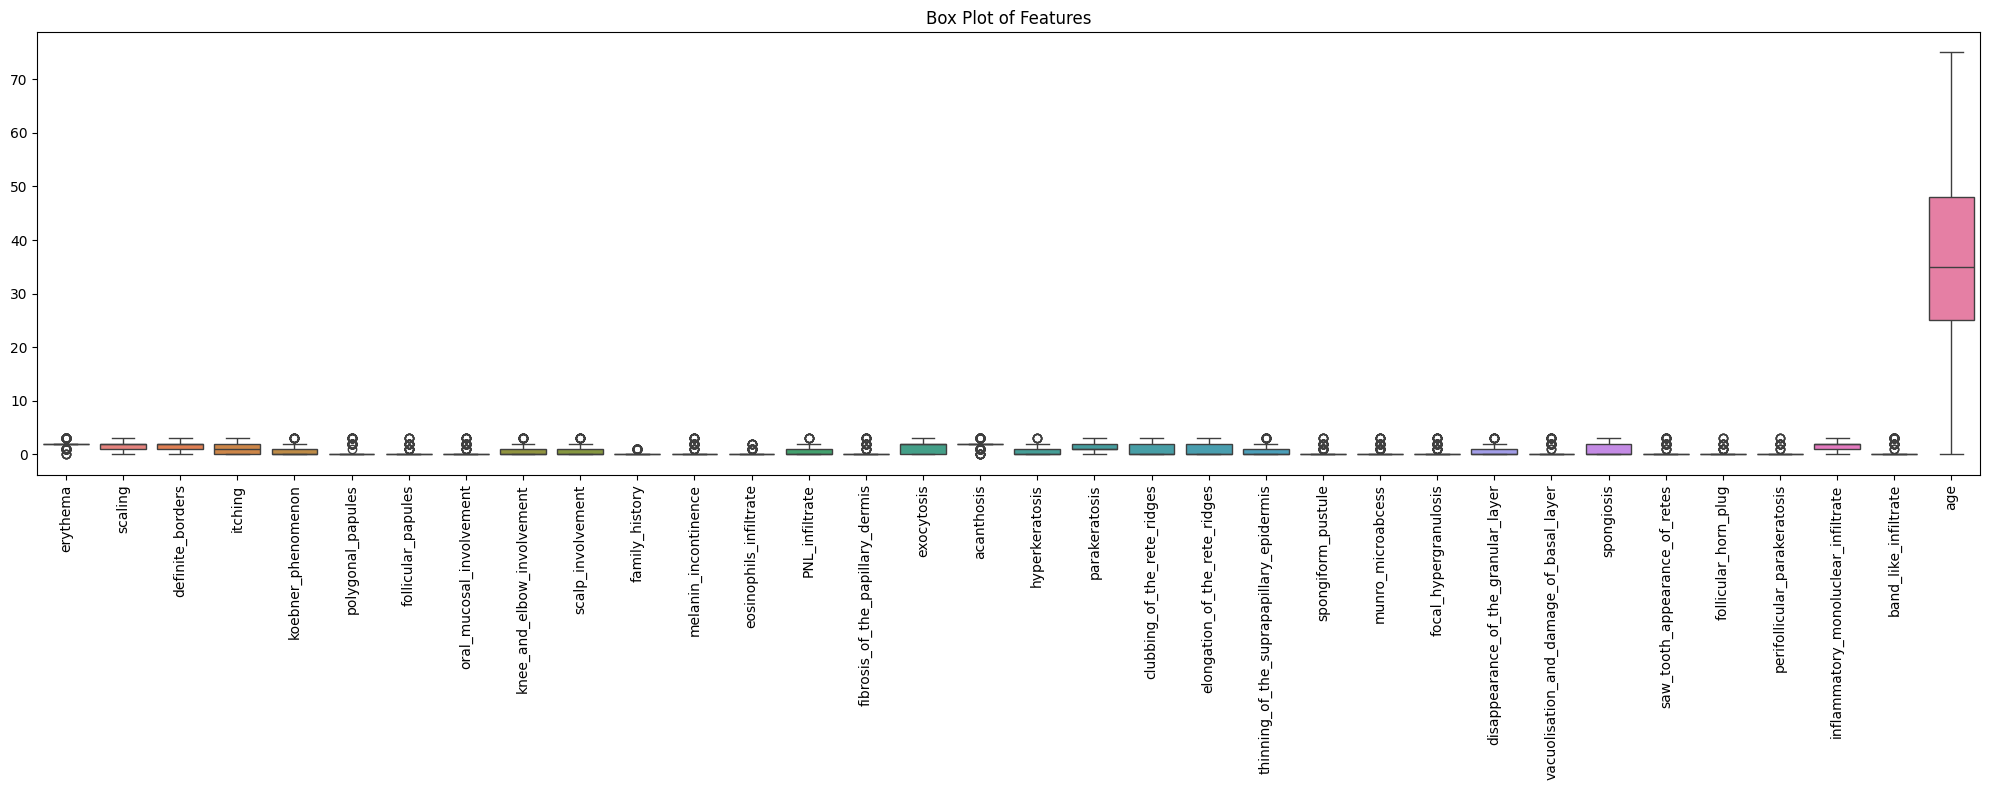

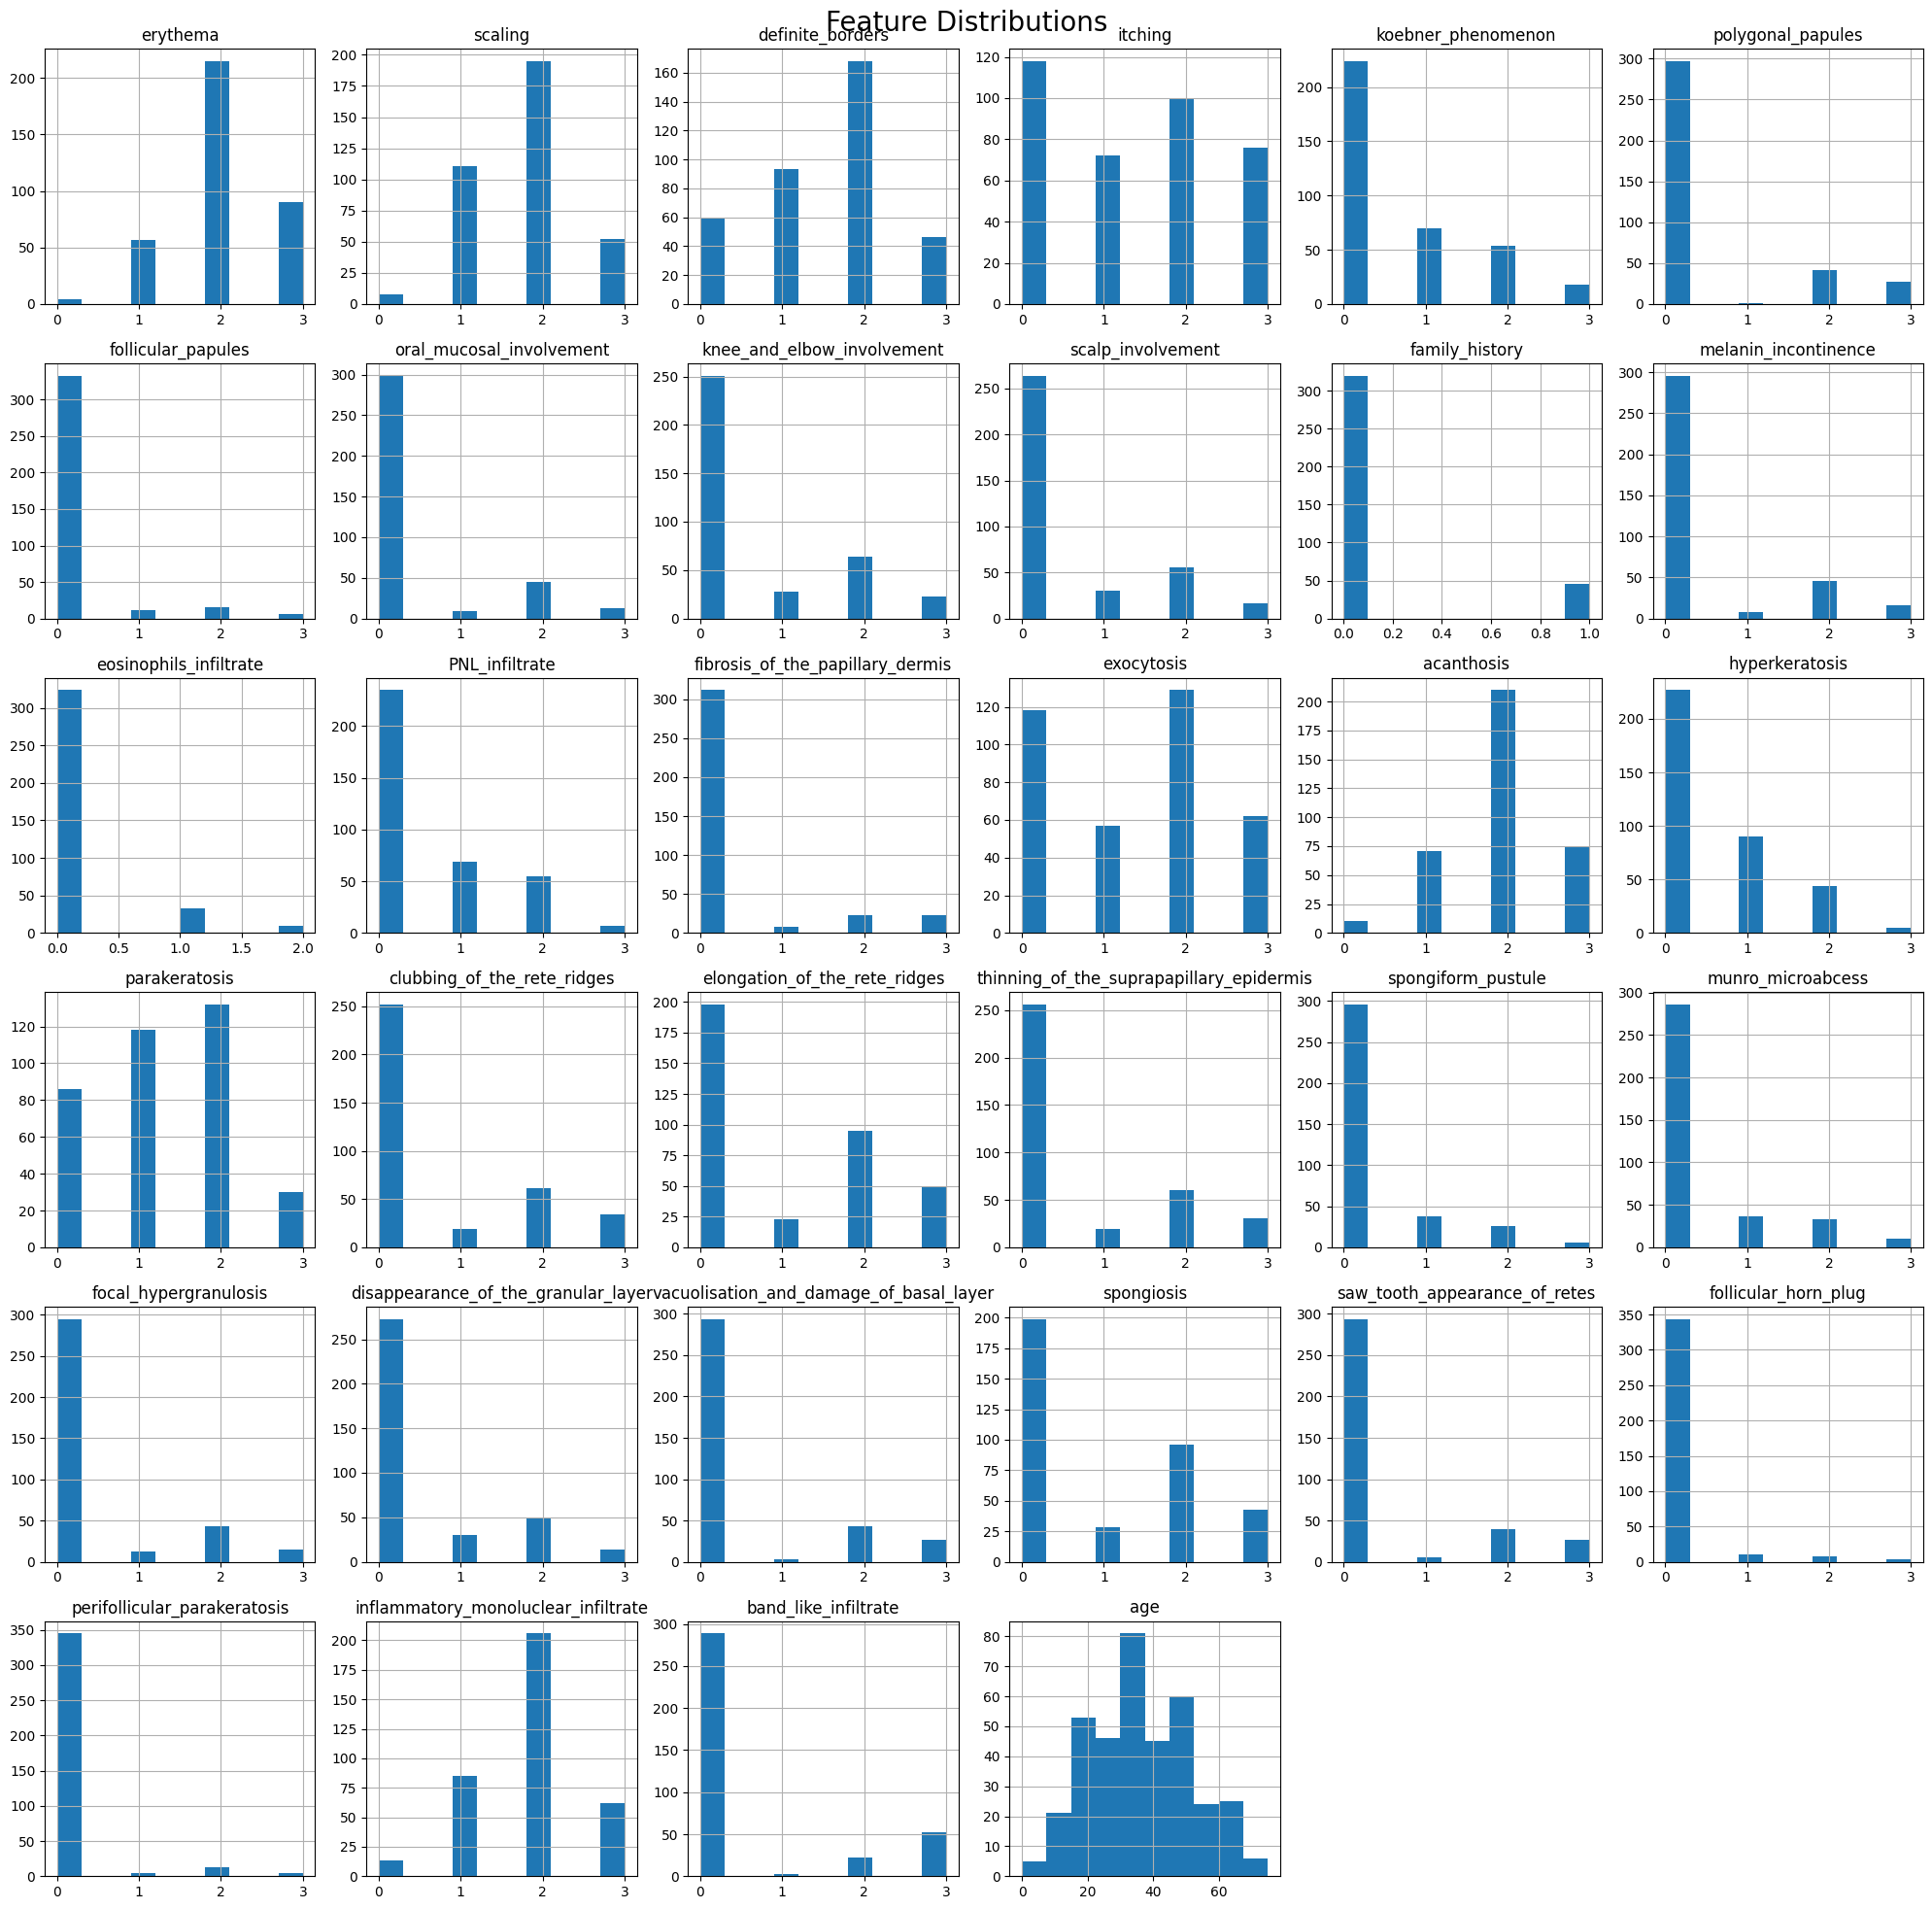


Class Distribution:
class
1    112
2     61
3     72
4     49
5     52
6     20
Name: count, dtype: int64


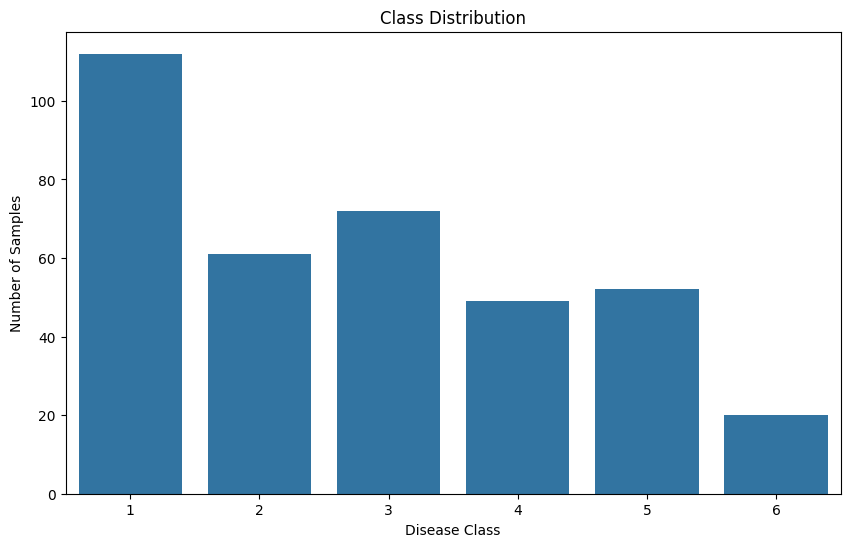


Class Percentages:
1 - Psoriasis: 30.60%
2 - Seborrheic Dermatitis: 16.67%
3 - Lichen Planus: 19.67%
4 - Pityriasis Rosea: 13.39%
5 - Chronic Dermatitis: 14.21%
6 - Pityriasis Rubra Pilaris: 5.46%


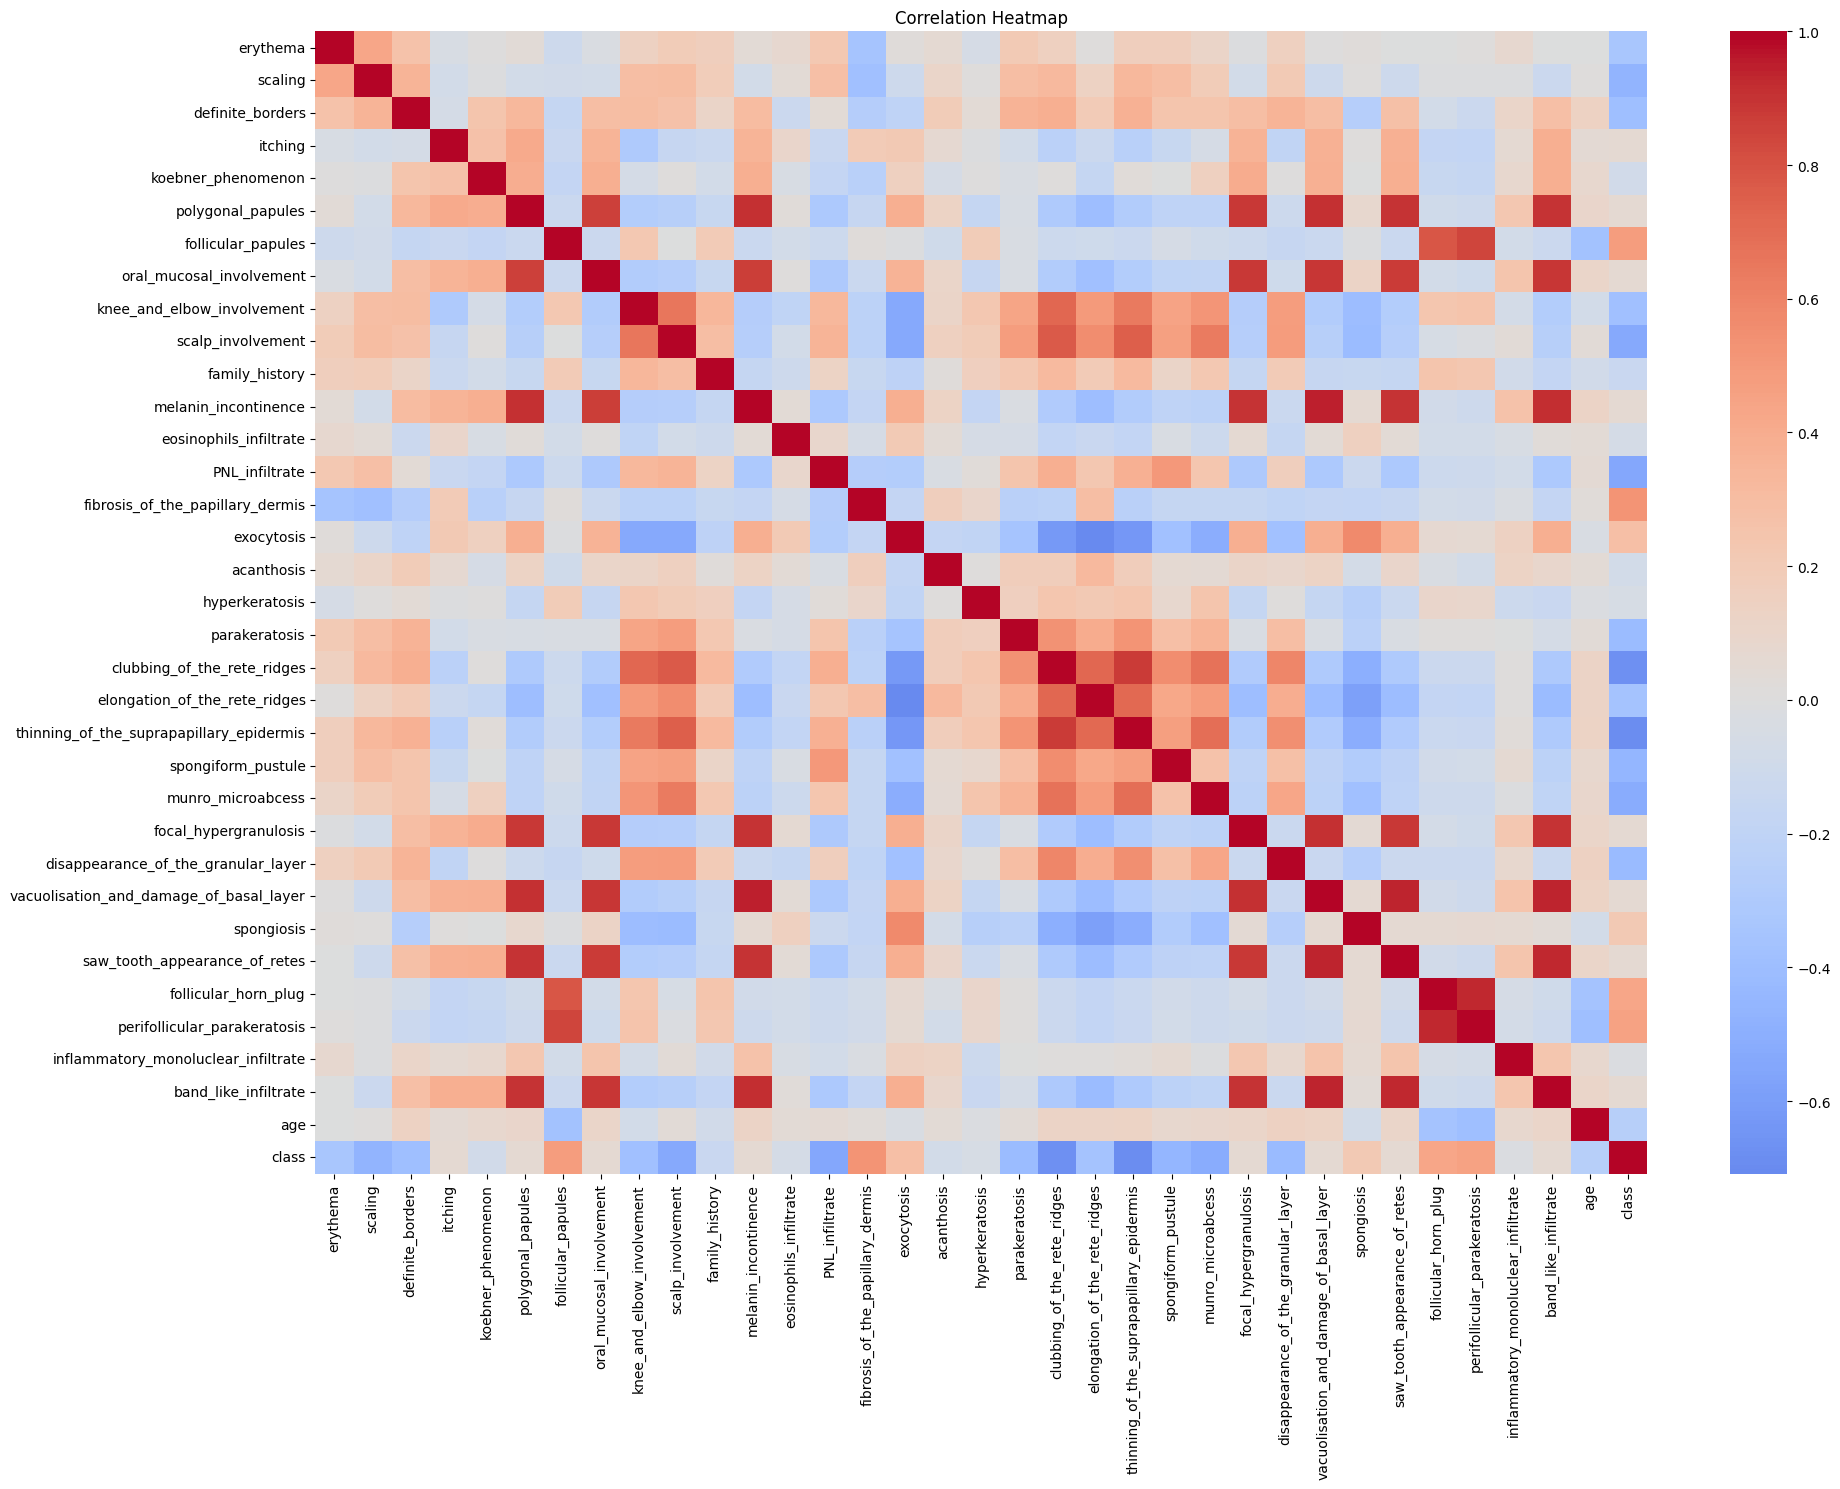


Training Shape: (292, 34)
Testing Shape: (74, 34)

Model Comparison:
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.9595     0.9688  0.9595    0.9606   0.9991
                KNN    0.9054     0.9193  0.9054    0.9081   0.9871
      Random Forest    0.9595     0.9607  0.9595    0.9595   0.9986
                SVM    0.9730     0.9775  0.9730    0.9730   0.9983

Logistic Regression
                          precision    recall  f1-score   support

               Psoriasis       1.00      1.00      1.00        23
   Seborrheic Dermatitis       1.00      0.83      0.91        12
           Lichen Planus       1.00      0.93      0.97        15
        Pityriasis Rosea       0.77      1.00      0.87        10
      Chronic Dermatitis       1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       1.00      1.00      1.00         4

                accuracy                           0.96        74
               macro avg       0.96    

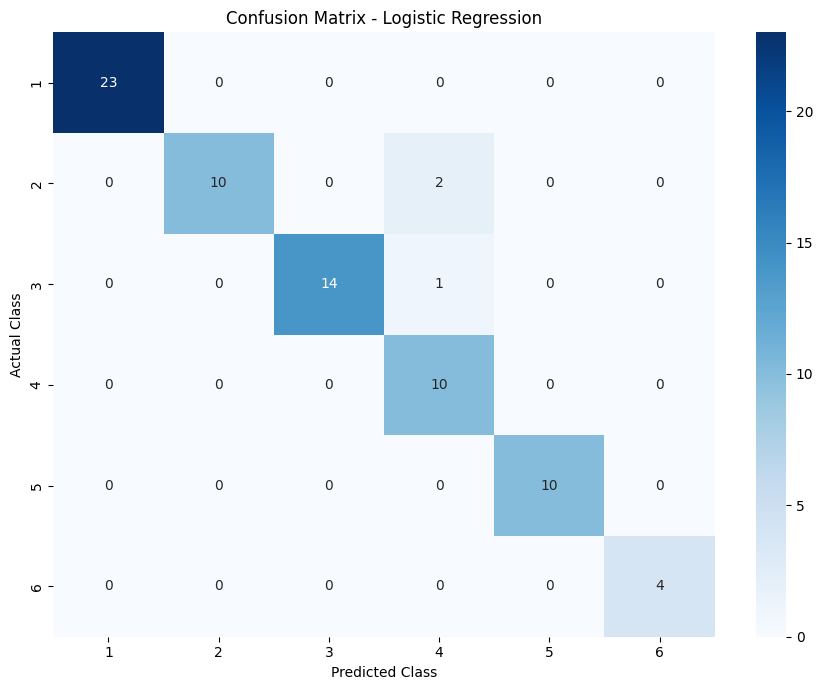


KNN
                          precision    recall  f1-score   support

               Psoriasis       1.00      0.96      0.98        23
   Seborrheic Dermatitis       0.80      0.67      0.73        12
           Lichen Planus       1.00      0.93      0.97        15
        Pityriasis Rosea       0.64      0.90      0.75        10
      Chronic Dermatitis       1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       1.00      1.00      1.00         4

                accuracy                           0.91        74
               macro avg       0.91      0.91      0.90        74
            weighted avg       0.92      0.91      0.91        74



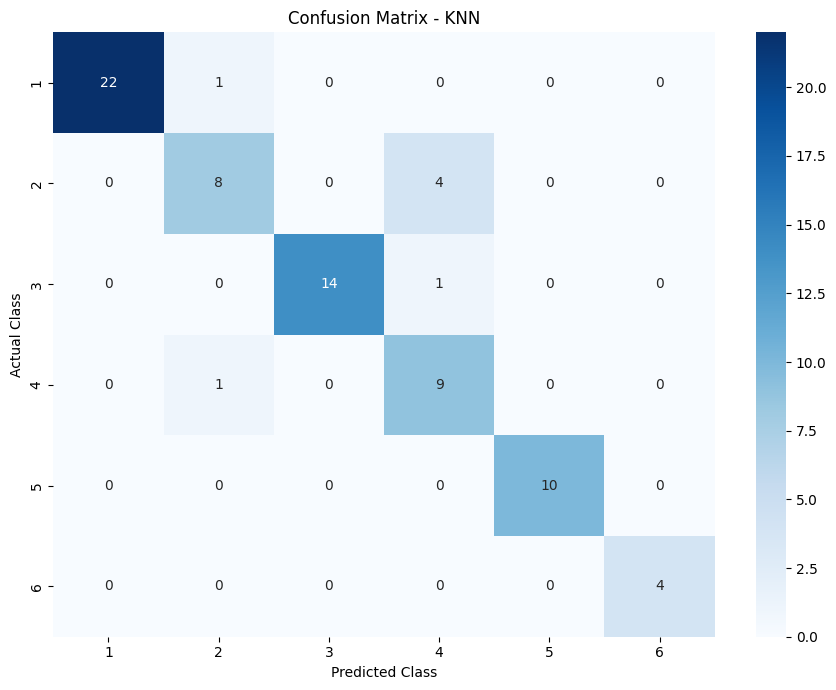


Random Forest
                          precision    recall  f1-score   support

               Psoriasis       1.00      1.00      1.00        23
   Seborrheic Dermatitis       0.91      0.83      0.87        12
           Lichen Planus       1.00      1.00      1.00        15
        Pityriasis Rosea       0.82      0.90      0.86        10
      Chronic Dermatitis       1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       1.00      1.00      1.00         4

                accuracy                           0.96        74
               macro avg       0.95      0.96      0.95        74
            weighted avg       0.96      0.96      0.96        74



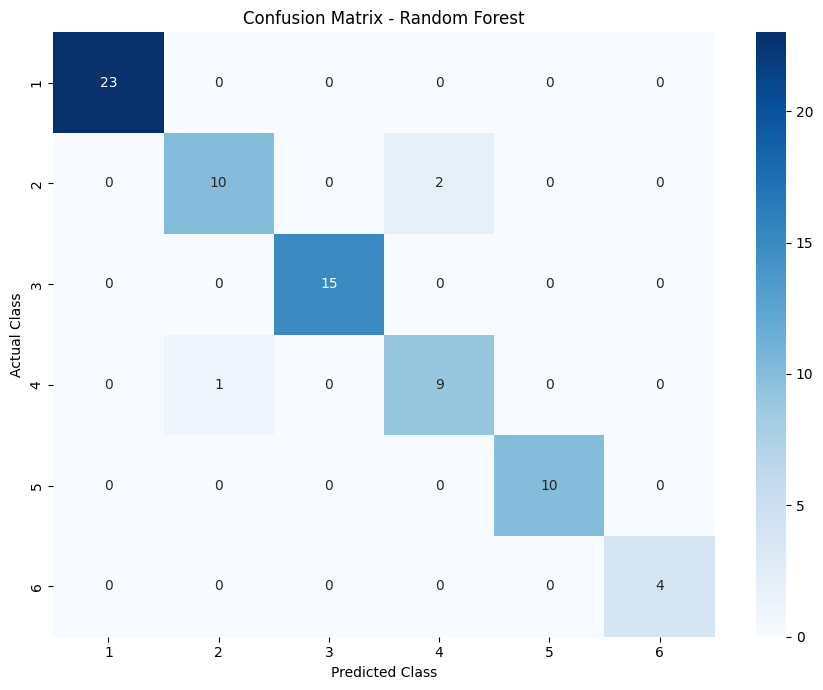


SVM
                          precision    recall  f1-score   support

               Psoriasis       1.00      1.00      1.00        23
   Seborrheic Dermatitis       1.00      0.83      0.91        12
           Lichen Planus       1.00      1.00      1.00        15
        Pityriasis Rosea       0.83      1.00      0.91        10
      Chronic Dermatitis       1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       1.00      1.00      1.00         4

                accuracy                           0.97        74
               macro avg       0.97      0.97      0.97        74
            weighted avg       0.98      0.97      0.97        74



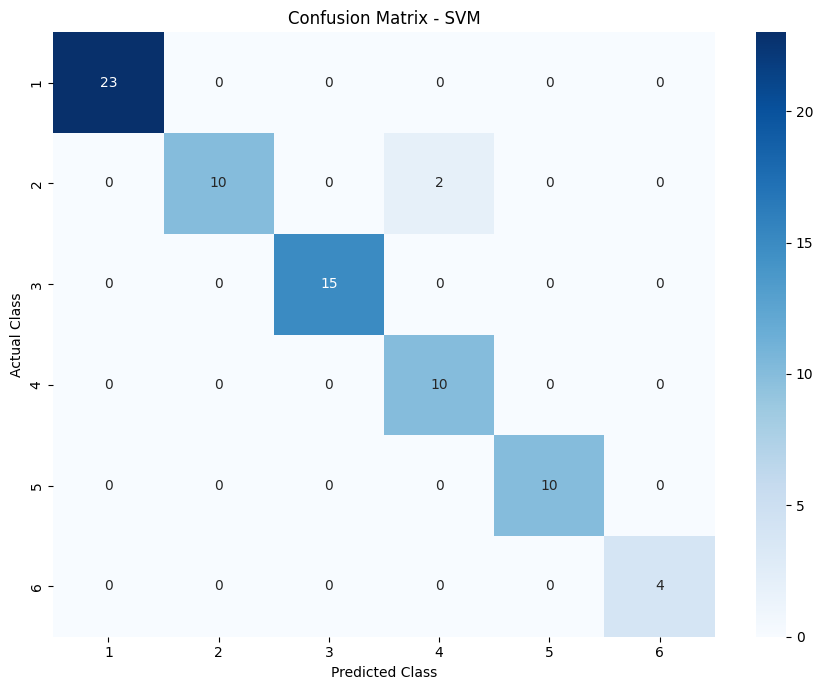

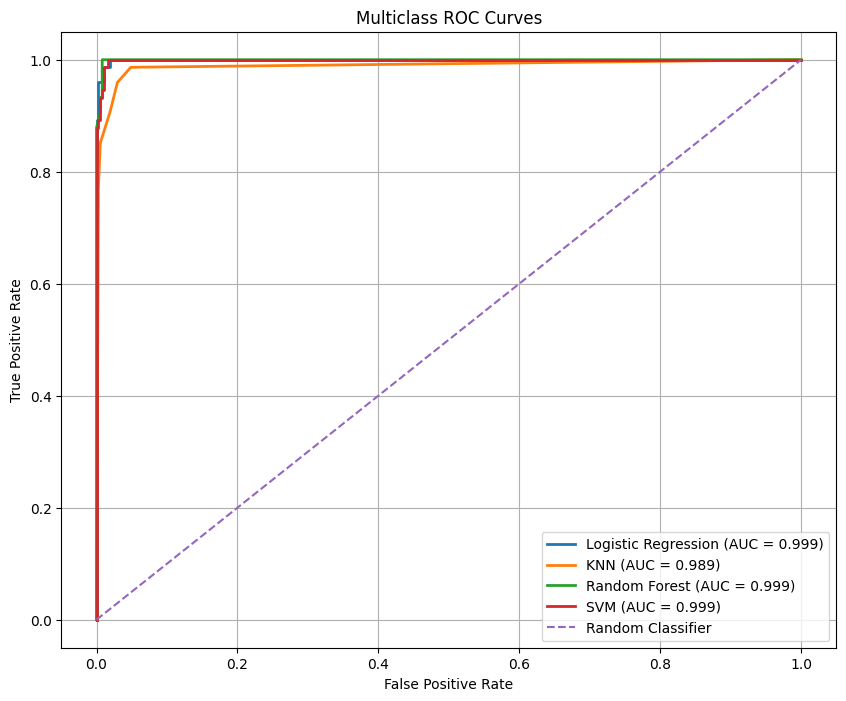

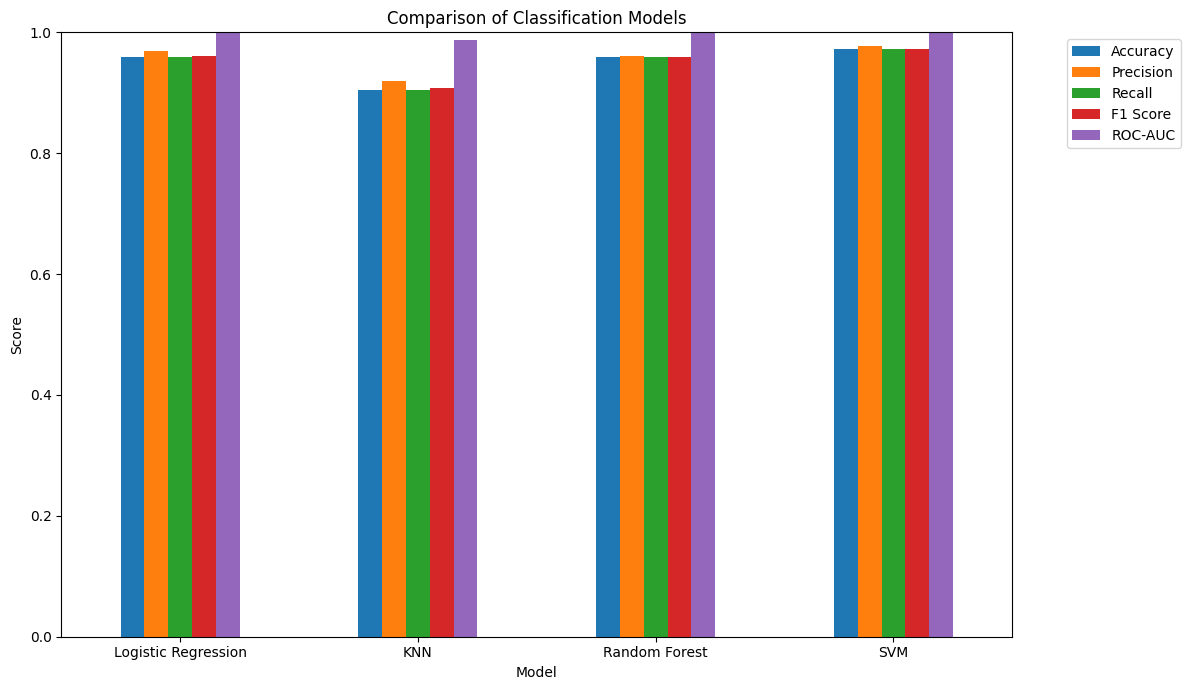


Best Accuracy:
Model             SVM
Accuracy     0.972973
Precision    0.977477
Recall       0.972973
F1 Score     0.972973
ROC-AUC      0.998284
Name: 3, dtype: object

Best F1 Score:
Model             SVM
Accuracy     0.972973
Precision    0.977477
Recall       0.972973
F1 Score     0.972973
ROC-AUC      0.998284
Name: 3, dtype: object

Best ROC-AUC:
Model        Logistic Regression
Accuracy                0.959459
Precision               0.968815
Recall                  0.959459
F1 Score                0.960642
ROC-AUC                 0.999135
Name: 0, dtype: object


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/dermatology/dermatology.data"

columns = [
    "erythema",
    "scaling",
    "definite_borders",
    "itching",
    "koebner_phenomenon",
    "polygonal_papules",
    "follicular_papules",
    "oral_mucosal_involvement",
    "knee_and_elbow_involvement",
    "scalp_involvement",
    "family_history",
    "melanin_incontinence",
    "eosinophils_infiltrate",
    "PNL_infiltrate",
    "fibrosis_of_the_papillary_dermis",
    "exocytosis",
    "acanthosis",
    "hyperkeratosis",
    "parakeratosis",
    "clubbing_of_the_rete_ridges",
    "elongation_of_the_rete_ridges",
    "thinning_of_the_suprapapillary_epidermis",
    "spongiform_pustule",
    "munro_microabcess",
    "focal_hypergranulosis",
    "disappearance_of_the_granular_layer",
    "vacuolisation_and_damage_of_basal_layer",
    "spongiosis",
    "saw_tooth_appearance_of_retes",
    "follicular_horn_plug",
    "perifollicular_parakeratosis",
    "inflammatory_monoluclear_infiltrate",
    "band_like_infiltrate",
    "age",
    "class"
]

df = pd.read_csv(
    url,
    header=None,
    names=columns,
    na_values="?"
)

df = df.apply(pd.to_numeric, errors="coerce")

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

for column in df.columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

print("\nMissing Values After Handling:")
print(df.isnull().sum().sum())

print("\nSummary Statistics:")
print(df.describe().T)

print("\nMedian:")
print(df.median())

X_temp = df.drop("class", axis=1)

Q1 = X_temp.quantile(0.25)
Q3 = X_temp.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (
    (X_temp < lower_bound) |
    (X_temp > upper_bound)
)

print("\nOutliers:")
print(outliers.sum())

plt.figure(figsize=(20, 8))
sns.boxplot(data=X_temp)
plt.title("Box Plot of Features")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

X_temp.hist(figsize=(20, 20), bins=10)
plt.suptitle("Feature Distributions", fontsize=20)
plt.tight_layout()
plt.show()

print("\nClass Distribution:")
print(df["class"].value_counts().sort_index())

disease_names = {
    1: "Psoriasis",
    2: "Seborrheic Dermatitis",
    3: "Lichen Planus",
    4: "Pityriasis Rosea",
    5: "Chronic Dermatitis",
    6: "Pityriasis Rubra Pilaris"
}

plt.figure(figsize=(10, 6))
sns.countplot(x="class", data=df)
plt.title("Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")
plt.show()

print("\nClass Percentages:")

class_percentage = (
    df["class"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

for class_id, percentage in class_percentage.items():
    print(
        f"{class_id} - {disease_names[class_id]}: "
        f"{percentage:.2f}%"
    )

plt.figure(figsize=(20, 15))
sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=5000)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)

svm_model = SVC(
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)

models = {
    "Logistic Regression": (y_pred_lr, y_prob_lr),
    "KNN": (y_pred_knn, y_prob_knn),
    "Random Forest": (y_pred_rf, y_prob_rf),
    "SVM": (y_pred_svm, y_prob_svm)
}

results = []

for model_name, (y_pred, y_prob) in models.items():

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

print("\nModel Comparison:")
print(results_df.round(4).to_string(index=False))

target_names = [
    "Psoriasis",
    "Seborrheic Dermatitis",
    "Lichen Planus",
    "Pityriasis Rosea",
    "Chronic Dermatitis",
    "Pityriasis Rubra Pilaris"
]

for model_name, (y_pred, y_prob) in models.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=target_names
        )
    )

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(9, 7))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=range(1, 7),
        yticklabels=range(1, 7)
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.tight_layout()
    plt.show()

classes = sorted(y.unique())

y_test_binary = label_binarize(
    y_test,
    classes=classes
)

plt.figure(figsize=(10, 8))

for model_name, (y_pred, y_prob) in models.items():

    fpr, tpr, _ = roc_curve(
        y_test_binary.ravel(),
        y_prob.ravel()
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves")
plt.legend()
plt.grid()
plt.show()

results_plot = results_df.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Comparison of Classification Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

print("\nBest Accuracy:")
print(
    results_df.loc[
        results_df["Accuracy"].idxmax()
    ]
)

print("\nBest F1 Score:")
print(
    results_df.loc[
        results_df["F1 Score"].idxmax()
    ]
)

print("\nBest ROC-AUC:")
print(
    results_df.loc[
        results_df["ROC-AUC"].idxmax()
    ]
)